In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../dados/dados_analise.csv", encoding="latin1", sep=";")

print("--- Primeiras 5 linhas da base de dados ---")
print(df.head())

print("\n--- Informações do DataFrame ---")
print(df.info())

--- Primeiras 5 linhas da base de dados ---
   ID Entrevistado  Unnamed: 1 Sucessão Rural  Unnamed: 3  \
0                1         NaN            Sim         NaN   
1                2         NaN            Sim         NaN   
2                3         NaN            Sim         NaN   
3                4         NaN            Sim         NaN   
4                5         NaN            Sim         NaN   

  Coleta de água da chuva  Unnamed: 5  Unnamed: 6 Qualidade de internet  
0                     Sim         NaN         NaN                   Bom  
1                     Sim         NaN         NaN                   Bom  
2                     Sim         NaN         NaN                   Bom  
3                     Sim         NaN         NaN                   Bom  
4                     Sim         NaN         NaN                   Bom  

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 8 columns):
 #   Colu

In [23]:
print("--- Sucessão Rural ---")
print(df['Sucessão Rural'].value_counts(normalize=True) * 100)

print("\n--- Coleta Água da Chuva ---")
print(df['Coleta de água da chuva'].value_counts(normalize=True) * 100)

print("\n--- Qualidade de Internet ---")
print(df['Qualidade de internet'].value_counts(normalize=True) * 100)

--- Sucessão Rural ---
Sucessão Rural
Sim    57.142857
Não    42.857143
Name: proportion, dtype: float64

--- Coleta Água da Chuva ---
Coleta de água da chuva
Não    82.142857
Sim    17.857143
Name: proportion, dtype: float64

--- Qualidade de Internet ---
Qualidade de internet
Bom        46.428571
Regular    32.142857
Ruim       14.285714
Ótimo       7.142857
Name: proportion, dtype: float64


In [20]:
# 1. Remover automaticamente todas as colunas que começam com "Unnamed"
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 2. Verificar as colunas restantes
print("Colunas limpas:", df.columns.tolist())

Colunas limpas: ['ID Entrevistado', 'Sucessão Rural', 'Coleta de água da chuva', 'Qualidade de internet']


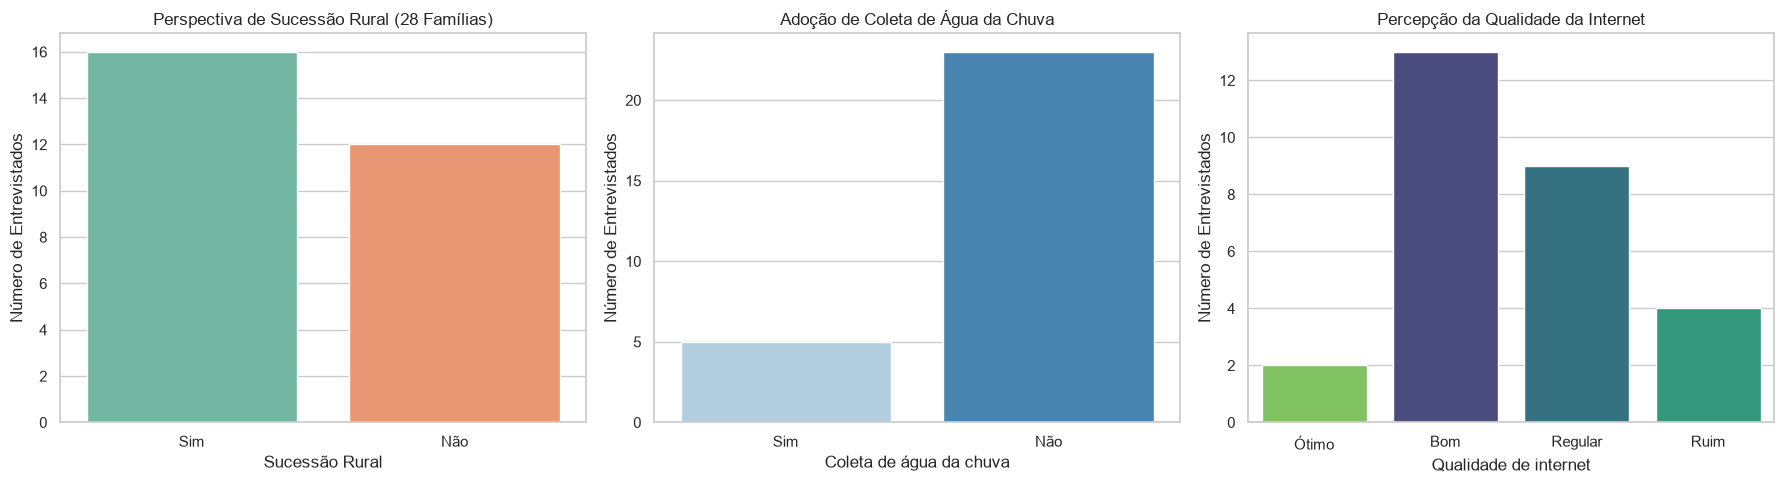

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=df, 
    x='Sucessão Rural', 
    hue='Sucessão Rural', 
    ax=axes[0], 
    palette='Set2', 
    legend=False
)
axes[0].set_title('Perspectiva de Sucessão Rural (28 Famílias)')
axes[0].set_ylabel('Número de Entrevistados')

sns.countplot(
    data=df, 
    x='Coleta de água da chuva', 
    hue='Coleta de água da chuva', 
    ax=axes[1], 
    palette='Blues', 
    legend=False
)
axes[1].set_title('Adoção de Coleta de Água da Chuva')
axes[1].set_ylabel('Número de Entrevistados')

sns.countplot(
    data=df, 
    x='Qualidade de internet', 
    hue='Qualidade de internet', 
    ax=axes[2], 
    palette='viridis', 
    order=['Ótimo', 'Bom', 'Regular', 'Ruim'], 
    legend=False
)
axes[2].set_title('Percepção da Qualidade da Internet')
axes[2].set_ylabel('Número de Entrevistados')

plt.tight_layout()
plt.show()

In [27]:
ct_internet = pd.crosstab(
    df['Sucessão Rural'],
    df['Qualidade de internet'],
    normalize='index'
) * 100

print("--- Sucessão Rural vs Qualidade de internet (%) ---")
print(ct_internet.round(2))

print("\n" + "="*55 + "\n")

ct_agua = pd.crosstab(
    df['Sucessão Rural'],
    df['Coleta de água da chuva'],
    normalize='index'
) * 100

print("--- Sucessão Rural vs Coleta de água da chuva (%) ---")
print(ct_agua.round(2))

--- Sucessão Rural vs Qualidade de internet (%) ---
Qualidade de internet    Bom  Regular   Ruim  Ótimo
Sucessão Rural                                     
Não                     8.33    41.67  33.33  16.67
Sim                    75.00    25.00   0.00   0.00


--- Sucessão Rural vs Coleta de água da chuva (%) ---
Coleta de água da chuva     Não    Sim
Sucessão Rural                        
Não                      100.00   0.00
Sim                       68.75  31.25


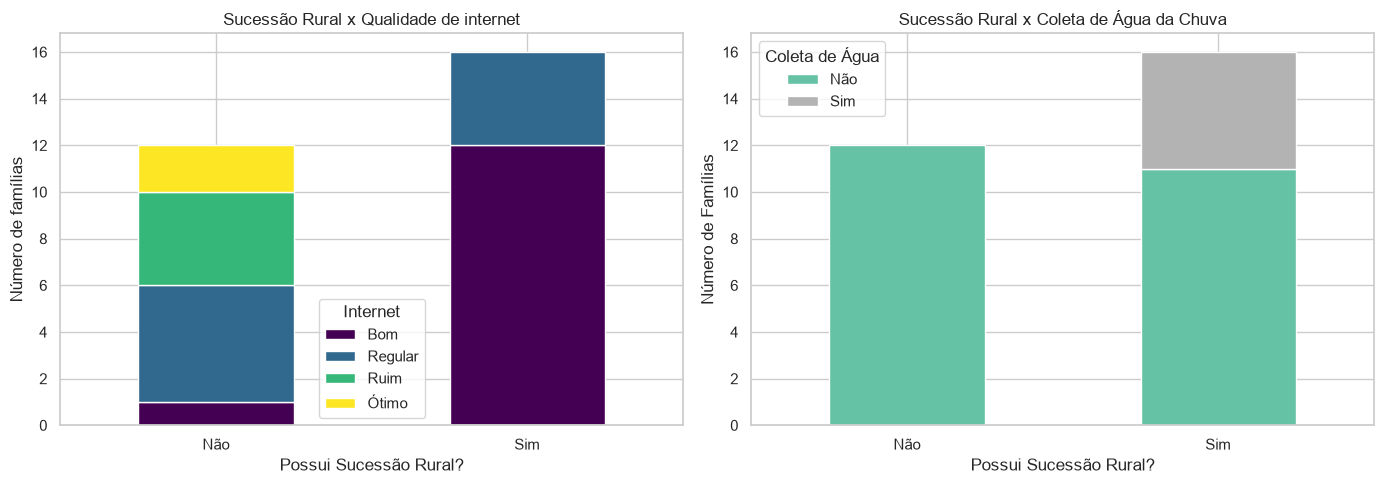

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(df['Sucessão Rural'], df['Qualidade de internet']).plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='viridis'
)
axes[0].set_title('Sucessão Rural x Qualidade de internet')
axes[0].set_xlabel('Possui Sucessão Rural?')
axes[0].set_ylabel('Número de famílias')
axes[0].legend(title='Internet')
axes[0].tick_params(axis='x', rotation=0)

pd.crosstab(df['Sucessão Rural'], df['Coleta de água da chuva']).plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1], 
    colormap='Set2'
)
axes[1].set_title('Sucessão Rural x Coleta de Água da Chuva')
axes[1].set_xlabel('Possui Sucessão Rural?')
axes[1].set_ylabel('Número de Famílias')
axes[1].legend(title='Coleta de Água')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../dados/grafico_analise_bivariada.png', dpi=300, bbox_inches='tight')
plt.show()